In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor, BaggingRegressor

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import warnings
warnings.filterwarnings('ignore')


### Load Dataset

In [2]:
data = fetch_california_housing(as_frame=True)
df = data.frame

print("Shape:", df.shape)
print("\nFeature Names:", list(df.columns))
df.head()

Shape: (20640, 9)

Feature Names: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude', 'MedHouseVal']


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


### EDA

In [3]:
print("=== Missing Values ===")
print(df.isnull().sum())

print("\n=== Basic Statistics ===")
df.describe()

=== Missing Values ===
MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64

=== Basic Statistics ===


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


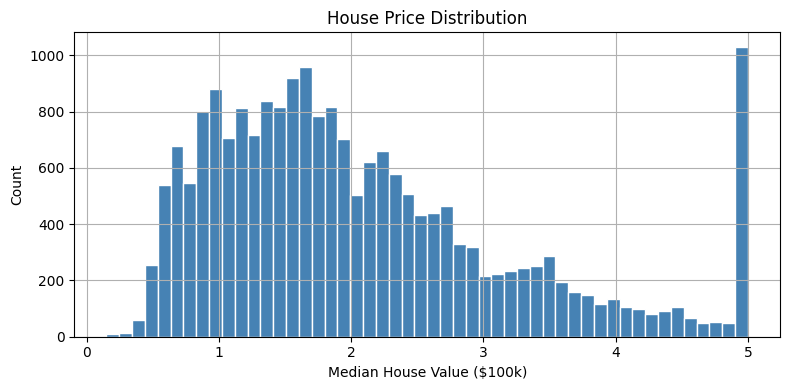

In [4]:
# Target distribution
plt.figure(figsize=(8, 4))
df['MedHouseVal'].hist(bins=50, color='steelblue', edgecolor='white')
plt.title('House Price Distribution')
plt.xlabel('Median House Value ($100k)')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

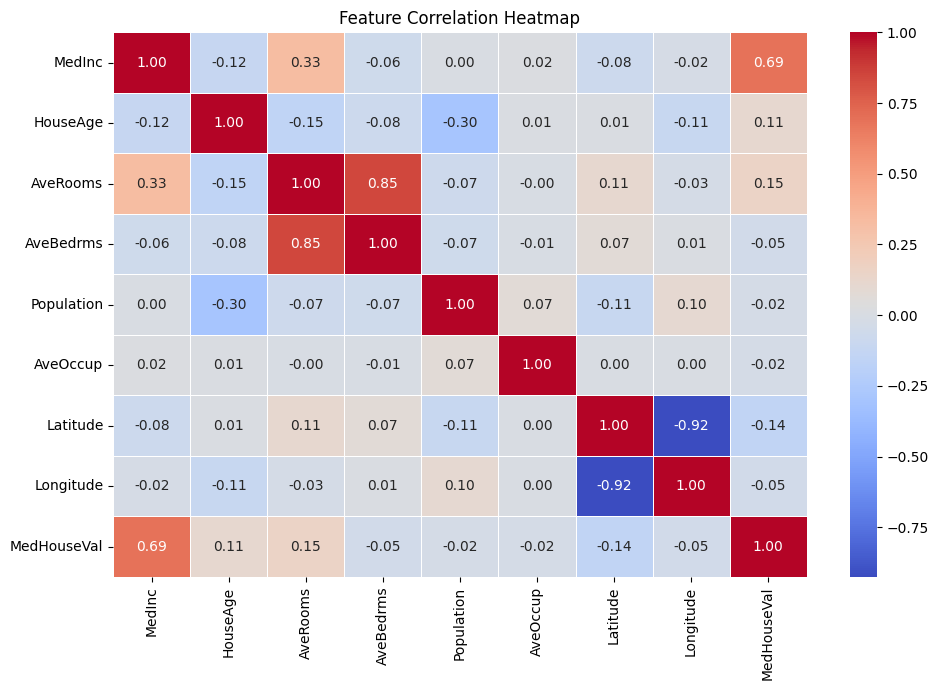

In [5]:
# Correlation heatmap
plt.figure(figsize=(10, 7))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()

### Pre Processing


In [6]:
# Features and target
X = df.drop(columns=['MedHouseVal'])
y = df['MedHouseVal']

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Scale features (required for KNN, SVM, PCA)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print("Train size:", X_train.shape)
print("Test size: ", X_test.shape)

Train size: (16512, 8)
Test size:  (4128, 8)


### PCA 

In [7]:
# Apply PCA — keep components that explain 95% variance
pca = PCA(n_components=0.95, random_state=42)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca  = pca.transform(X_test_scaled)

print(f"Original features : {X_train_scaled.shape[1]}")
print(f"After PCA         : {X_train_pca.shape[1]}")
print(f"Variance explained: {sum(pca.explained_variance_ratio_)*100:.2f}%")

Original features : 8
After PCA         : 6
Variance explained: 98.37%


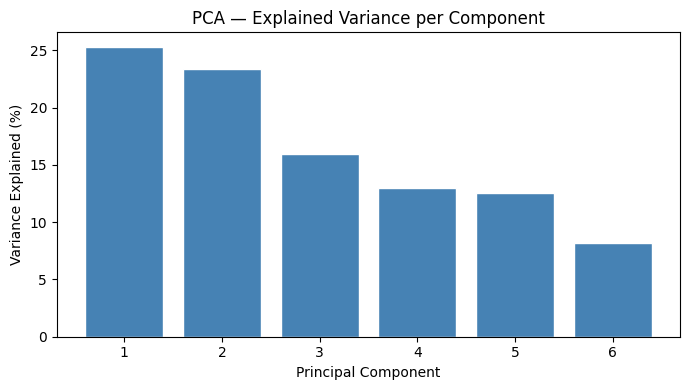

In [8]:
# Plot explained variance
plt.figure(figsize=(7, 4))
plt.bar(range(1, len(pca.explained_variance_ratio_)+1),
        pca.explained_variance_ratio_ * 100, color='steelblue', edgecolor='white')
plt.xlabel('Principal Component')
plt.ylabel('Variance Explained (%)')
plt.title('PCA — Explained Variance per Component')
plt.tight_layout()
plt.show()

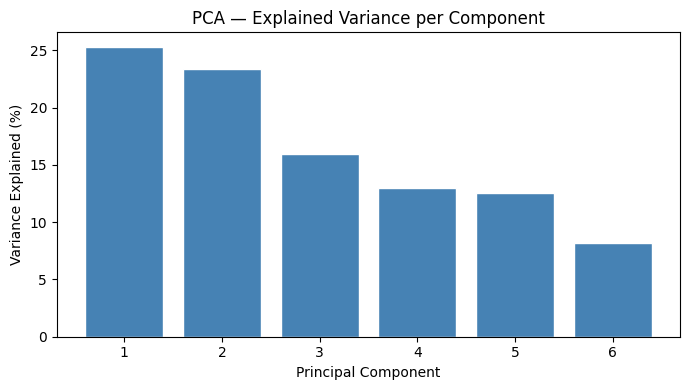

In [9]:
# Plot explained variance
plt.figure(figsize=(7, 4))
plt.bar(range(1, len(pca.explained_variance_ratio_)+1),
        pca.explained_variance_ratio_ * 100, color='steelblue', edgecolor='white')
plt.xlabel('Principal Component')
plt.ylabel('Variance Explained (%)')
plt.title('PCA — Explained Variance per Component')
plt.tight_layout()
plt.show()

### Model 1: Decision Tree

In [11]:
results = []

def evaluate(name, y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)
    print(f"\n{'─'*40}")
    print(f"  {name}")
    print(f"{'─'*40}")
    print(f"  RMSE : {rmse:.4f}")
    print(f"  MAE  : {mae:.4f}")
    print(f"  R²   : {r2:.4f}  ({r2*100:.1f}% accuracy)")
    results.append({'Model': name, 'RMSE': rmse, 'MAE': mae, 'R2': r2})

# ── Decision Tree ──
dt = DecisionTreeRegressor(max_depth=6, random_state=42)
dt.fit(X_train, y_train)
dt_pred = dt.predict(X_test)

evaluate("Decision Tree", y_test, dt_pred)


────────────────────────────────────────
  Decision Tree
────────────────────────────────────────
  RMSE : 0.7052
  MAE  : 0.5008
  R²   : 0.6205  (62.1% accuracy)


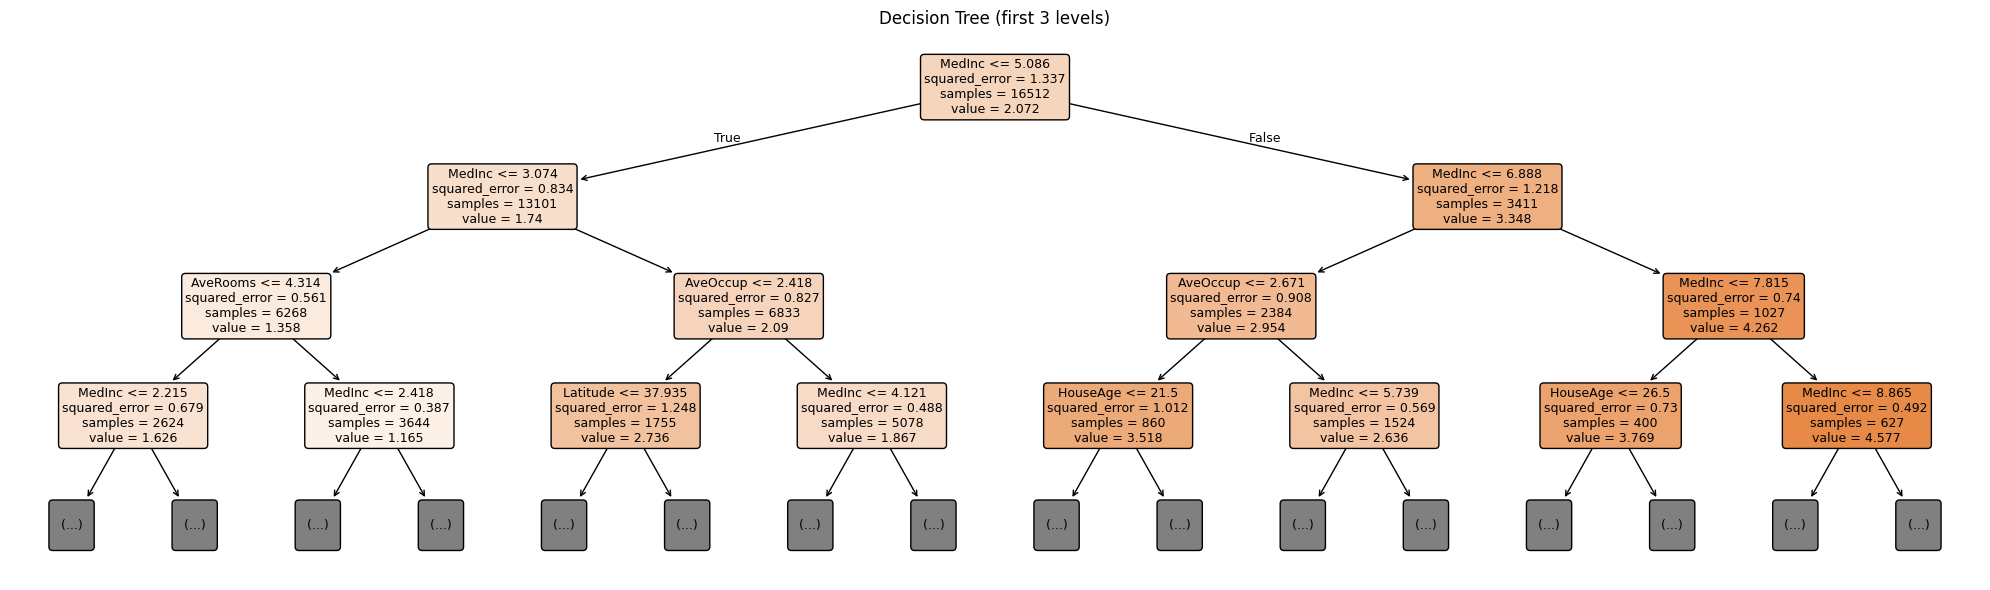

In [12]:
# Visualize the tree (top 3 levels)
plt.figure(figsize=(20, 6))
plot_tree(dt, max_depth=3, feature_names=X.columns.tolist(),
          filled=True, rounded=True, fontsize=9)
plt.title('Decision Tree (first 3 levels)')
plt.tight_layout()
plt.show()

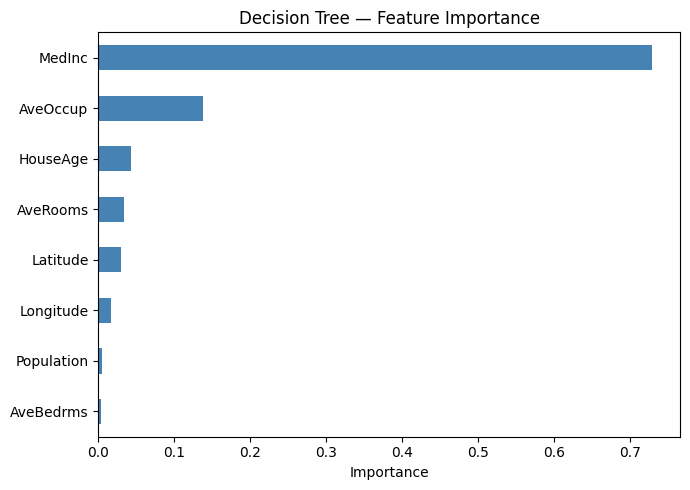

In [13]:
# Feature importance
importances = pd.Series(dt.feature_importances_, index=X.columns)
importances.sort_values().plot(kind='barh', figsize=(7, 5), color='steelblue')
plt.title('Decision Tree — Feature Importance')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

### Model 2: KNN

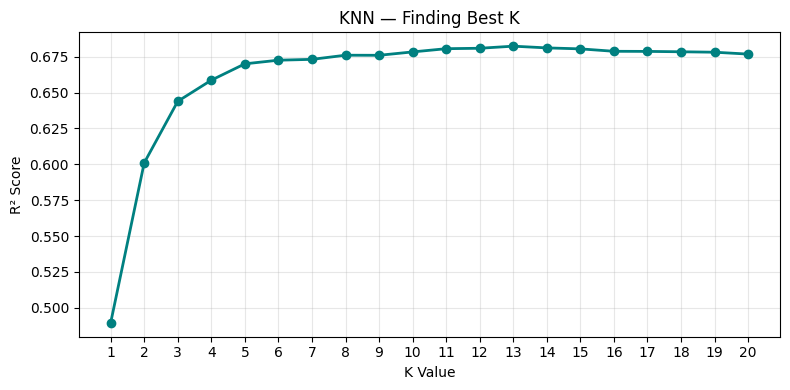

Best K: 13  |  Best R²: 0.6823


In [14]:
# Find best K value
k_values = range(1, 21)
k_scores = []

for k in k_values:
    knn = KNeighborsRegressor(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    pred = knn.predict(X_test_scaled)
    k_scores.append(r2_score(y_test, pred))

# Plot K vs R²
plt.figure(figsize=(8, 4))
plt.plot(k_values, k_scores, marker='o', color='teal', linewidth=2)
plt.xlabel('K Value')
plt.ylabel('R² Score')
plt.title('KNN — Finding Best K')
plt.xticks(k_values)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

best_k = k_values[np.argmax(k_scores)]
print(f"Best K: {best_k}  |  Best R²: {max(k_scores):.4f}")

In [15]:
# Train with best K
knn = KNeighborsRegressor(n_neighbors=best_k)
knn.fit(X_train_scaled, y_train)
knn_pred = knn.predict(X_test_scaled)

evaluate(f"KNN (K={best_k})", y_test, knn_pred)


────────────────────────────────────────
  KNN (K=13)
────────────────────────────────────────
  RMSE : 0.6452
  MAE  : 0.4373
  R²   : 0.6823  (68.2% accuracy)


### Model 3: SVM (SVR)

In [18]:
# SVM for regression = SVR
# Using PCA-reduced data (SVR is slow on large datasets)
svr = SVR(kernel='rbf', C=1.0, epsilon=0.1)
svr.fit(X_train_pca, y_train)
svr_pred = svr.predict(X_test_pca)

evaluate("SVM (SVR)", y_test, svr_pred)


────────────────────────────────────────
  SVM (SVR)
────────────────────────────────────────
  RMSE : 0.7011
  MAE  : 0.4780
  R²   : 0.6249  (62.5% accuracy)


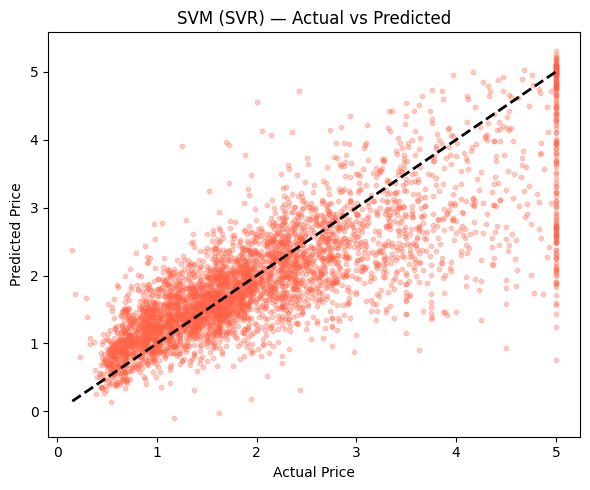

In [17]:
# Actual vs Predicted plot for SVR
plt.figure(figsize=(6, 5))
plt.scatter(y_test, svr_pred, alpha=0.3, s=10, color='tomato')
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()], 'k--', lw=2)
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('SVM (SVR) — Actual vs Predicted')
plt.tight_layout()
plt.show()

### Model 4: Ensemble (Bagging / Random Forest)


In [19]:
# Random Forest = Bagging with Decision Trees
rf = RandomForestRegressor(n_estimators=100, max_depth=15,
                           random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

evaluate("Random Forest (Bagging)", y_test, rf_pred)


────────────────────────────────────────
  Random Forest (Bagging)
────────────────────────────────────────
  RMSE : 0.5115
  MAE  : 0.3332
  R²   : 0.8004  (80.0% accuracy)


In [22]:
# Also show explicit BaggingRegressor (directly from your lab)
bag = BaggingRegressor(n_estimators=50, random_state=42, n_jobs=-1)
bag.fit(X_train, y_train)
bag_pred = bag.predict(X_test)

evaluate("Bagging Regressor", y_test, bag_pred)


────────────────────────────────────────
  Bagging Regressor
────────────────────────────────────────
  RMSE : 0.5072
  MAE  : 0.3300
  R²   : 0.8036  (80.4% accuracy)


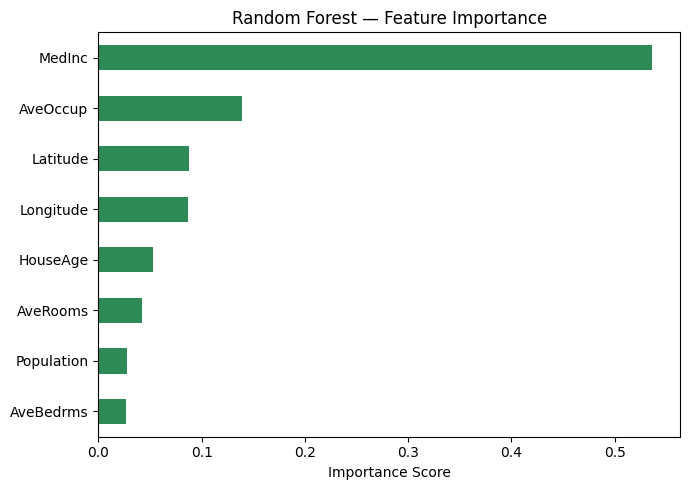

In [21]:
# Feature importance
importances = pd.Series(rf.feature_importances_, index=X.columns)
importances.sort_values().plot(kind='barh', figsize=(7, 5), color='seagreen')
plt.title('Random Forest — Feature Importance')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

### Compare All Models

In [25]:
results_df = pd.DataFrame(results).sort_values('R2', ascending=False)
print("FINAL MODEL COMPARISON")
print(results_df.to_string(index=False))

FINAL MODEL COMPARISON
                  Model     RMSE      MAE       R2
      Bagging Regressor 0.507246 0.330000 0.803650
      Bagging Regressor 0.507246 0.330000 0.803650
Random Forest (Bagging) 0.511481 0.333232 0.800358
             KNN (K=13) 0.645205 0.437303 0.682321
              SVM (SVR) 0.701115 0.478023 0.624879
              SVM (SVR) 0.701115 0.478023 0.624879
          Decision Tree 0.705184 0.500804 0.620513


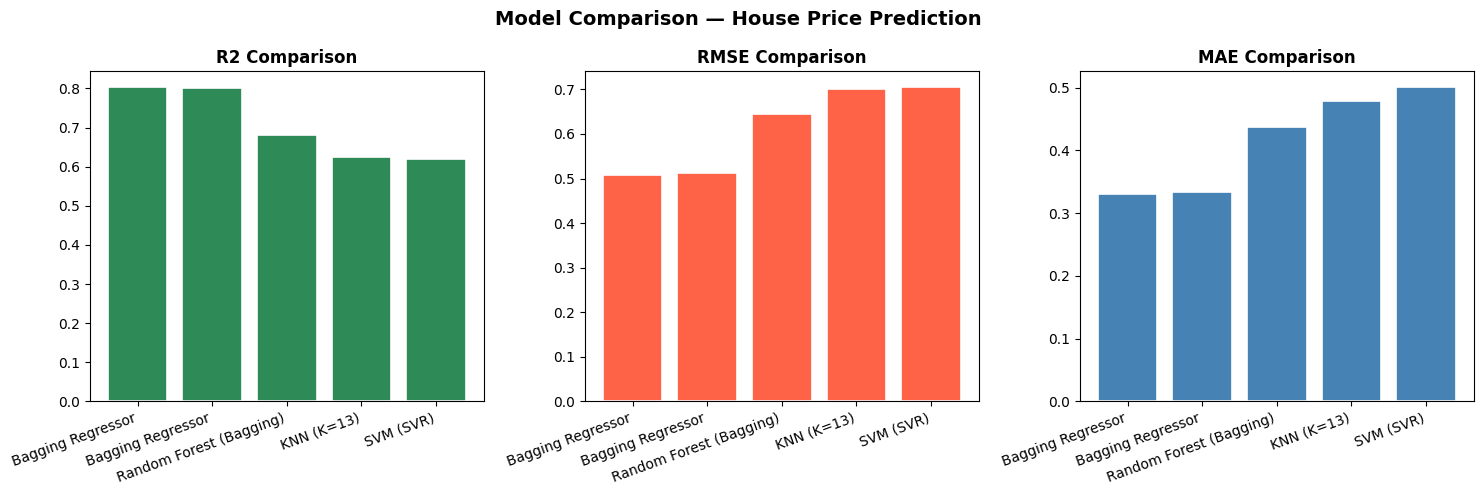

In [26]:
# Bar chart comparison
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
metrics = ['R2', 'RMSE', 'MAE']
colors  = ['seagreen', 'tomato', 'steelblue']

for ax, metric, color in zip(axes, metrics, colors):
    ax.bar(results_df['Model'], results_df[metric],
           color=color, edgecolor='white', linewidth=1.2)
    ax.set_title(f'{metric} Comparison', fontweight='bold')
    ax.set_xticklabels(results_df['Model'], rotation=20, ha='right')

plt.suptitle('Model Comparison — House Price Prediction', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

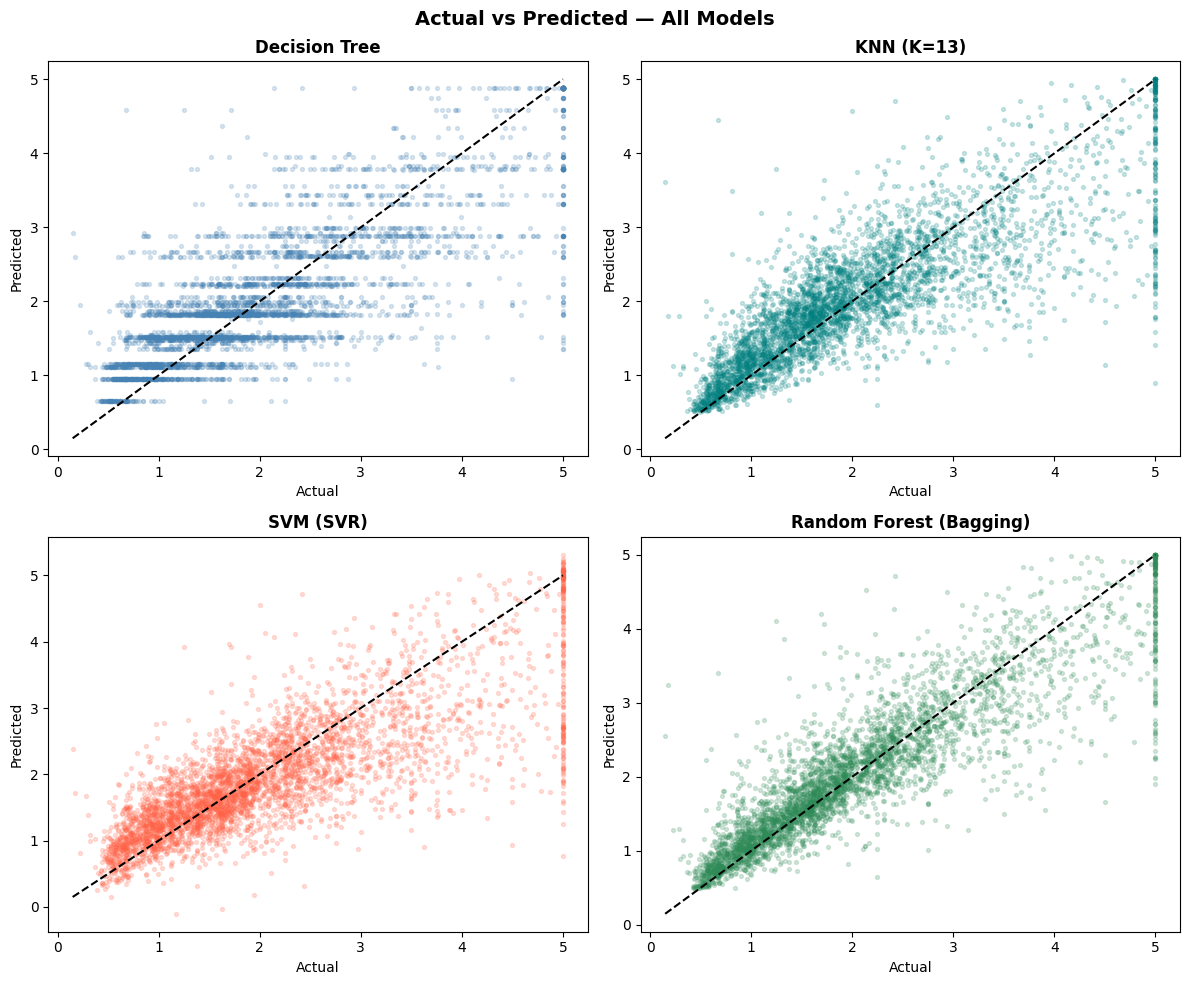

In [27]:
# Actual vs Predicted for all 4 models
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
models_info = [
    ("Decision Tree",          y_test, dt_pred,  'steelblue'),
    (f"KNN (K={best_k})",      y_test, knn_pred, 'teal'),
    ("SVM (SVR)",              y_test, svr_pred,  'tomato'),
    ("Random Forest (Bagging)",y_test, rf_pred,   'seagreen'),
]

for ax, (name, actual, predicted, color) in zip(axes.flatten(), models_info):
    ax.scatter(actual, predicted, alpha=0.2, s=8, color=color)
    ax.plot([actual.min(), actual.max()],
            [actual.min(), actual.max()], 'k--', lw=1.5)
    ax.set_title(name, fontweight='bold')
    ax.set_xlabel('Actual')
    ax.set_ylabel('Predicted')

plt.suptitle('Actual vs Predicted — All Models', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [28]:
best_model = results_df.iloc[0]

print("=" * 50)
print("        CONCLUSION — FINAL PROJECT")
print("=" * 50)
print(f"\n  Best Model : {best_model['Model']}")
print(f"  R² Score   : {best_model['R2']:.4f} ({best_model['R2']*100:.1f}% accuracy)")
print(f"  RMSE       : {best_model['RMSE']:.4f}")
print(f"  MAE        : {best_model['MAE']:.4f}")
print(f"\n  PCA reduced features from 8 → {X_train_pca.shape[1]}")
print(f"  while retaining 95%+ of variance.")
print("\n  Random Forest performed best because it builds")
print("  multiple trees and combines their predictions,")
print("  reducing overfitting compared to a single tree.")
print("=" * 50)

        CONCLUSION — FINAL PROJECT

  Best Model : Bagging Regressor
  R² Score   : 0.8036 (80.4% accuracy)
  RMSE       : 0.5072
  MAE        : 0.3300

  PCA reduced features from 8 → 6
  while retaining 95%+ of variance.

  Random Forest performed best because it builds
  multiple trees and combines their predictions,
  reducing overfitting compared to a single tree.


In [29]:
# A new house with these details:
new_house = pd.DataFrame([{
    'MedInc'    : 5.0,   # Median income in the area (in $10,000s)
    'HouseAge'  : 20.0,  # Age of the house in years
    'AveRooms'  : 6.0,   # Average number of rooms
    'AveBedrms' : 1.2,   # Average number of bedrooms
    'Population': 500.0, # Population in the block
    'AveOccup'  : 3.0,   # Average people per household
    'Latitude'  : 34.0,  # Location latitude
    'Longitude' : -118.0 # Location longitude (Los Angeles area)
}])

# Predict using all 4 models
dt_price  = dt.predict(new_house)[0]
knn_price = knn.predict(scaler.transform(new_house))[0]
svr_price = svr.predict(pca.transform(scaler.transform(new_house)))[0]
rf_price  = rf.predict(new_house)[0]

print("=" * 45)
print("   HOUSE PRICE PREDICTIONS")
print("=" * 45)
print(f"  Decision Tree    : ${dt_price  * 100000:,.0f}")
print(f"  KNN              : ${knn_price * 100000:,.0f}")
print(f"  SVM (SVR)        : ${svr_price * 100000:,.0f}")
print(f"  Random Forest    : ${rf_price  * 100000:,.0f}")
print("=" * 45)
print(f" ✅ Best Model (Random Forest): ${rf_price * 100000:,.0f}")
print("=" * 45)

   HOUSE PRICE PREDICTIONS
  Decision Tree    : $182,858
  KNN              : $265,892
  SVM (SVR)        : $219,999
  Random Forest    : $234,800
 ✅ Best Model (Random Forest): $234,800
